## TRAINING

In [1]:


import sys
import os

from pathlib import Path
from itertools import islice
sys.path.append(os.path.abspath('..'))


In [14]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
from src.encoder_decoder import Seq2SeqTransformer
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from src.dataset import TranslationDataset
from src.tokenizer import Tokenizer
from src.padding import dynamic_pad_collate
from src.train import train_step


In [3]:
swa_tokenizer = Tokenizer()
eng_tokenizer = Tokenizer()

In [4]:
## load_data

translationDataset = TranslationDataset(filepath="./../data/toy_translations.txt",eng_tokenizer=eng_tokenizer,swa_tokenizer=swa_tokenizer)


print(len(translationDataset))
print(translationDataset[633])

634
([3, 11, 278, 277, 2], [3, 447, 446], [447, 446, 2])


In [5]:
model = Seq2SeqTransformer(src_vocab_size=len(eng_tokenizer.word2int),tgt_vocab_size=len(swa_tokenizer.word2int),d_model=512,num_heads=8,num_layers=2,max_len=1000)

criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)


dataloader = DataLoader(dataset=translationDataset,batch_size=32,collate_fn=dynamic_pad_collate,shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
epochs = 1


best_val_loss = float('inf')


for epoch in range(epochs):
    
    model.train()
    
    running_loss = 0.0
    
    correct = 0
    
    total = 0
    
    
    
    
    for batch in dataloader:
        
        total,correct,running_loss = train_step(model,batch,optimizer,criterion,device,running_loss,total,correct)
        
        
    epoch_loss = running_loss /len(dataloader)
    
    train_accuracy = 100 * correct/total
    
    
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")

        
        

The loss is : 6.405971527099609
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 19.933691024780273
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 5.885285377502441
the shape of predicted indices is torch.Size([32, 4])
the shape of expected_labels is  torch.Size([128])
The loss is : 5.261222839355469
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 4.799748420715332
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 4.588344573974609
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 4.58599328994751
the shape of predicted indices is torch.Size([32, 5])
the shape of expected_labels is  torch.Size([160])
The loss is : 4.291884899139404
the shape

In [7]:

def translate_to_swa(input):
    
    #encode
    encoded_input = eng_tokenizer.encode(input)
    
    print(encoded_input)
    
    tensor_input = torch.tensor([encoded_input])
    print(f"shape of tensor_input :{tensor_input.shape}")
    
    
    model.eval()
    encoded_response,attention_weights = model.predict(tensor_input,3,2)
    
    
    print(encoded_response)
    
    decoded_response = swa_tokenizer.decode(encoded_response[1:-1])
    
    print(decoded_response)
    
    return decoded_response,attention_weights
    

In [8]:
response ,attention_weights= translate_to_swa("they go home")

[3, 12, 35, 41, 2]
shape of tensor_input :torch.Size([1, 5])
This is the shape of decoder weights: torch.Size([1, 8, 1, 5])
This is the shape of latest prediction: torch.Size([1, 448])
This is the shape of next_word_id: torch.Size([1])
This is the shape of unsqueezed next_word_id: torch.Size([1, 1])
This is the shape of decoder_input: torch.Size([1, 2])
This is the shape of last_token_generated: 43
This is the shape of decoder weights: torch.Size([1, 8, 2, 5])
This is the shape of latest prediction: torch.Size([1, 448])
This is the shape of next_word_id: torch.Size([1])
This is the shape of unsqueezed next_word_id: torch.Size([1, 1])
This is the shape of decoder_input: torch.Size([1, 3])
This is the shape of last_token_generated: 48
This is the shape of decoder weights: torch.Size([1, 8, 3, 5])
This is the shape of latest prediction: torch.Size([1, 448])
This is the shape of next_word_id: torch.Size([1])
This is the shape of unsqueezed next_word_id: torch.Size([1, 1])
This is the shape

In [9]:
# sample_sentences = ["i want to go home","you will sleep early","she read yesterday","i ate rice","the student is clever"]
# filepath = Path("./../experiments/sample_predictions.txt")

# filepath.parent.mkdir(parents=True, exist_ok=True)



# with open(filepath, "w", encoding="utf-8") as file:
#     for sentence in sample_sentences:
#         response ,weights= translate_to_swa(sentence)
#         file.write(f"input: {sentence} ,prediction: {response}\n\n")

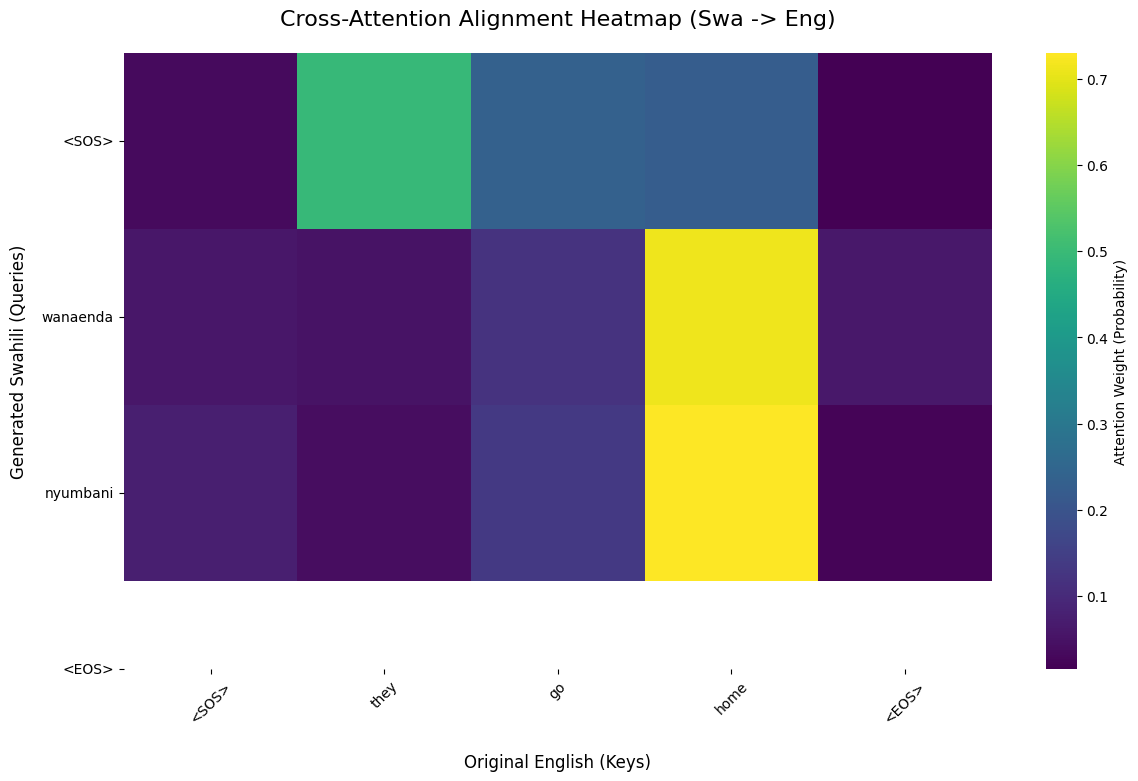

Heatmap successfully saved to: ../experiments/attention_final_weights.png


In [15]:
# 1. We assume 'attention_weights' is now a [swahili_seq_len, english_seq_len] tensor
# which you are getting back from your fixed 'predict' function.
matrix_to_plot = attention_weights.detach().cpu().numpy()

# Set up the plot size
plt.figure(figsize=(14, 8))

# 2. Configure the heatmap
sns.heatmap(matrix_to_plot, 
            cmap='viridis', 
            # 3. Use an accurate label for attention weights (0.0 to 1.0)
            cbar_kws={'label': 'Attention Weight (Probability)'})

# 4. Apply RIGOROUS, accurate professional labels
plt.title("Cross-Attention Alignment Heatmap (Swa -> Eng)", fontsize=16, pad=20)

# The generated tokens (rows) are Queries asking the source tokens (columns)
plt.ylabel("Generated Swahili (Queries)", fontsize=12, labelpad=10) 
plt.xlabel("Original English (Keys)", fontsize=12, labelpad=20)

# --- BONUS TIP FOR UNDERSTANDING ---
# To make it 'really' understandable, pass in the actual token strings to the heatmap axes!
# Assuming you have:
swa_tokens = ["<SOS>", "wanaenda", "nyumbani", "<EOS>"]
eng_tokens = ["<SOS>", "they", "go", "home", "<EOS>"]
# You would add these lines right before plt.savefig():
plt.xticks(np.arange(len(eng_tokens)) + 0.5, eng_tokens, rotation=45)
plt.yticks(np.arange(len(swa_tokens)) + 0.5, swa_tokens, rotation=0)

# Save the final figure
filepath = Path('./../experiments/attention_final_weights.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()
print(f"Heatmap successfully saved to: {filepath}")

In [ ]:
S